In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import libpysal.weights as weights
from pysal.explore import esda
import matplotlib.pyplot as plt

/Users/jacobwiniski/anaconda3/lib/python3.10/site-packages/spaghetti/network.py:40: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


In [2]:
##################### Generate dummy data ############################

# Random distribution of quality along x and y
np.random.seed(42)  # for reproducibility
data = {
    'x': np.random.rand(200) * 100,
    'y': np.random.rand(200) * 100,
    'quality': np.random.rand(200)
}
df_rando = pd.DataFrame(data)

# Gradient of quality values along x and y with clustering of high and low values
# Generate random x and y values
x_values = np.random.rand(200) * 100
y_values = np.random.rand(200) * 100

# Normalize x and y to be between 0 and 1
x_normalized = (x_values - x_values.min()) / (x_values.max() - x_values.min())
y_normalized = (y_values - y_values.min()) / (y_values.max() - y_values.min())

# Generate 'quality' as the average of normalized 'x' and 'y'
quality = 0.5 * (x_normalized + y_normalized)

data = {
    'x': x_values,
    'y': y_values,
    'quality': quality
}
df_gradient1 = pd.DataFrame(data)

# Gradient of quality values with different weightings from the one above (more intermixing of quality values)
np.random.seed(42)  # for reproducibility

# Generate random x and y values
x_values = np.random.rand(200) * 100
y_values = np.random.rand(200) * 100

# Calculate distances from the origin (0, 0) for each point
distances = np.sqrt(x_values**2 + y_values**2)
max_distance = np.max(distances)

# Determine quality based on distance
quality = []
for d in distances:
    if d < max_distance * 0.33:
        quality.append(np.random.uniform(0.7, 1.0))  # high-quality values close to origin
    elif d < max_distance * 0.66:
        quality.append(np.random.uniform(0.4, 0.7))  # mixed values in the middle
    else:
        quality.append(np.random.uniform(0.0, 1.0))  # even mix of low and high values far from origin

data = {
    'x': x_values,
    'y': y_values,
    'quality': quality
}
df_gradient2 = pd.DataFrame(data)

#Create distribution where a high value is placed in close proximity to every two low values in combination with the gradient above
x_values = np.random.rand(200) * 100
y_values = np.random.rand(200) * 100

# Normalize x and y to be between 0 and 1
x_normalized = (x_values - x_values.min()) / (x_values.max() - x_values.min())
y_normalized = (y_values - y_values.min()) / (y_values.max() - y_values.min())

# Generate 'quality' as the average of normalized 'x' and 'y'
quality = 0.5 * (x_normalized + y_normalized)

# Creating a DataFrame
df = pd.DataFrame({'x': x_values, 'y': y_values, 'quality': quality})

# Sort the DataFrame by quality
df = df.sort_values(by='quality')

# Introduce a high 'quality' value for every two low 'quality' values
new_rows = []
for i in range(0, len(df)-2, 3):  # step of 3 to account for two lows and one high
    low_1, low_2 = df.iloc[i], df.iloc[i+1]
    # Perturb x and y slightly to position the high 'quality' value close to the two low values
    x_high = (low_1['x'] + low_2['x']) / 2 + np.random.uniform(-2, 2)
    y_high = (low_1['y'] + low_2['y']) / 2 + np.random.uniform(-2, 2)
    quality_high = 0.9  # or another high value
    new_rows.append({'x': x_high, 'y': y_high, 'quality': quality_high})

# Add the new rows to the DataFrame
df = df.append(new_rows, ignore_index=True)

# Rename the DataFrame as df_gradient1
df_gradient3 = df

#Distribution where low and high values are evenly dispersed
# Create a grid of points
x_values = np.random.rand(200) * 100
y_values = np.random.rand(200) * 100

# Calculate the median for x and y to split into quadrants
x_median = np.median(x_values)
y_median = np.median(y_values)

# Generate 'quality' values based on quadrant
quality = []
for x, y in zip(x_values, y_values):
    if (x <= x_median and y <= y_median) or (x > x_median and y > y_median):  # bottom-left or top-right quadrant
        quality.append(np.random.choice([0.8, 0.2]))  # mix of high and low
    else:  # top-left or bottom-right quadrant
        quality.append(np.random.choice([0.8, 0.2]))  # mix of high and low

data = {
    'x': x_values,
    'y': y_values,
    'quality': quality
}
df_dispersed = pd.DataFrame(data)

# Data above but making all points equidistant from one another
# Determine the number of points along each axis for a grid
n_points = int(np.sqrt(200))  # For 200 total points, we'll have a 14x14 grid

# Create a grid of equidistant points
x_values = np.linspace(0, 100, n_points)
y_values = np.linspace(0, 100, n_points)
x_values, y_values = np.meshgrid(x_values, y_values)
x_values = x_values.flatten()
y_values = y_values.flatten()

# Calculate the median for x and y to split into quadrants
x_median = np.median(x_values)
y_median = np.median(y_values)

# Generate 'quality' values based on quadrant
quality = []
for x, y in zip(x_values, y_values):
    if (x <= x_median and y <= y_median) or (x > x_median and y > y_median):  # bottom-left or top-right quadrant
        quality.append(np.random.choice([0.8, 0.2]))  # mix of high and low
    else:  # top-left or bottom-right quadrant
        quality.append(np.random.choice([0.8, 0.2]))  # mix of high and low

data = {
    'x': x_values,
    'y': y_values,
    'quality': quality
}
df_dispersed_eq = pd.DataFrame(data)

#Uncomment the data set you want to test
#df = df_rando #Random distribution
#df = df_gradient1 #Gradient from low to high values
#df = df_gradient2 #Gradient from high to intermixing of low and high values
#df = df_gradient3 #Gradient with secondary distribution high values in low proximity to low values
#df = df_dispersed #Even dispersion of low and high values
df = df_dispersed_eq #Even dispersion of low and high values where all points are equidistant

/var/folders/72/ncn0ph2x1334zkly0lnr956m0000gn/T/ipykernel_8363/3875971273.py:86: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(new_rows, ignore_index=True)


/Users/jacobwiniski/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/jacobwiniski/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/jacobwiniski/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/jacobwiniski/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warning

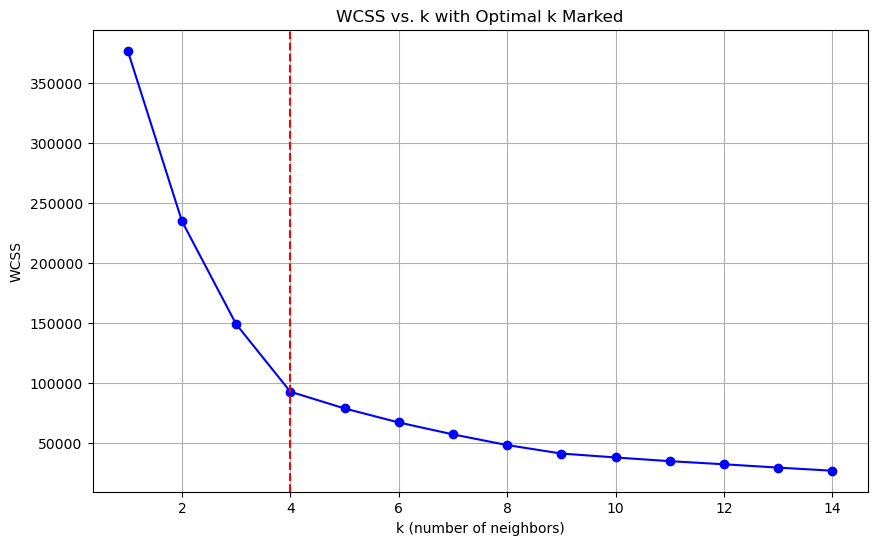

Optimal k value: 4


In [3]:
# Determine the optimum k value for the subsequent knn function
def plot_wcss_vs_k(coordinates, k_range):
    """
    Plot WCSS against k values for k-nearest neighbors and mark the inflection point.
    
    Args:
    - coordinates (array-like): Array of x, y coordinates.
    - k_range (range): Range of k values to test.
    """
    wcss = []  # within-cluster sum of squares
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(coordinates)
        wcss.append(kmeans.inertia_)
    
    # Calculate the distance of each WCSS point to a line connecting the first and last WCSS values
    x1, y1 = k_range[0], wcss[0]
    x2, y2 = k_range[-1], wcss[-1]
    distances = []
    for k, w in zip(k_range, wcss):
        # Distance formula for a point from a line (derived from the line equation)
        distance = np.abs((y2 - y1)*k - (x2 - x1)*w + x2*y1 - y2*x1) / np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
        distances.append(distance)
    
    # Find k value corresponding to the maximum distance
    optimal_k = k_range[np.argmax(distances)]
    
    # Plot results for visualization
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, wcss, marker='o', linestyle='-', color='b')
    plt.axvline(x=optimal_k, color='r', linestyle='--')
    plt.xlabel('k (number of neighbors)')
    plt.ylabel('WCSS')
    plt.title('WCSS vs. k with Optimal k Marked')
    plt.grid(True)
    plt.show()

    return optimal_k

# Extract coordinates
coordinates = df[['x', 'y', 'quality']].values

# Usage
k_range = range(1, 15)  # or another reasonable range based on your dataset
optimal_k = plot_wcss_vs_k(coordinates, k_range)
print(f"Optimal k value: {optimal_k}")

In [4]:
# Create a list of x, y coordinates
coordinates = df[['x', 'y']].values

# Construct a spatial weight matrix using k-nearest neighbors
# Using optimal k parameter per elbow tuning above
knn_w = weights.KNN(coordinates, k=optimal_k)

In [5]:
# Compute Moran's I
moran = esda.Moran(df['quality'], knn_w)
print(f"Moran's I: {moran.I}")
print(f"Expected I under random spatial distribution: {moran.EI}")
print(f"P-value: {moran.p_sim}")

# A positive Moran's I value indicates clustering of similar values.
# A negative Moran's I value indicates dispersion of similar values.
# A Moran's I value near zero indicates randomness.
# If the p-value is below a significance level (e.g., 0.05), then the spatial pattern is statistically significant.

Moran's I: 0.026120970282474006
Expected I under random spatial distribution: -0.005128205128205128
P-value: 0.268


In [6]:
# Local Indicators of Spatial Association (LISA)
# If global indicators (like Moran's I) suggest spatial autocorrelation, you can use LISA to identify specific areas of clustering or dispersion.
# Compute Local Moran's I
local_moran = esda.Moran_Local(df['quality'], knn_w)

#print(local_moran.Is)
#print(local_moran.p_sim)
#print(local_moran.q)

# local_moran.Is: The local Moran's I values for each observation.
# local_moran.p_sim: p-values for each observation. A low p-value (typically < 0.05) indicates that the spatial autocorrelation for that observation is statistically significant.
# local_moran.q: A quadrant value (1, 2, 3, or 4) indicating the type of spatial association for each observation:
    #1: High-High (an observation with a high value surrounded by neighbors with high values)
    #2: Low-High (an observation with a low value surrounded by neighbors with high values)
    #3: Low-Low (an observation with a low value surrounded by neighbors with low values)
    #4: High-Low (an observation with a high value surrounded by neighbors with low values)

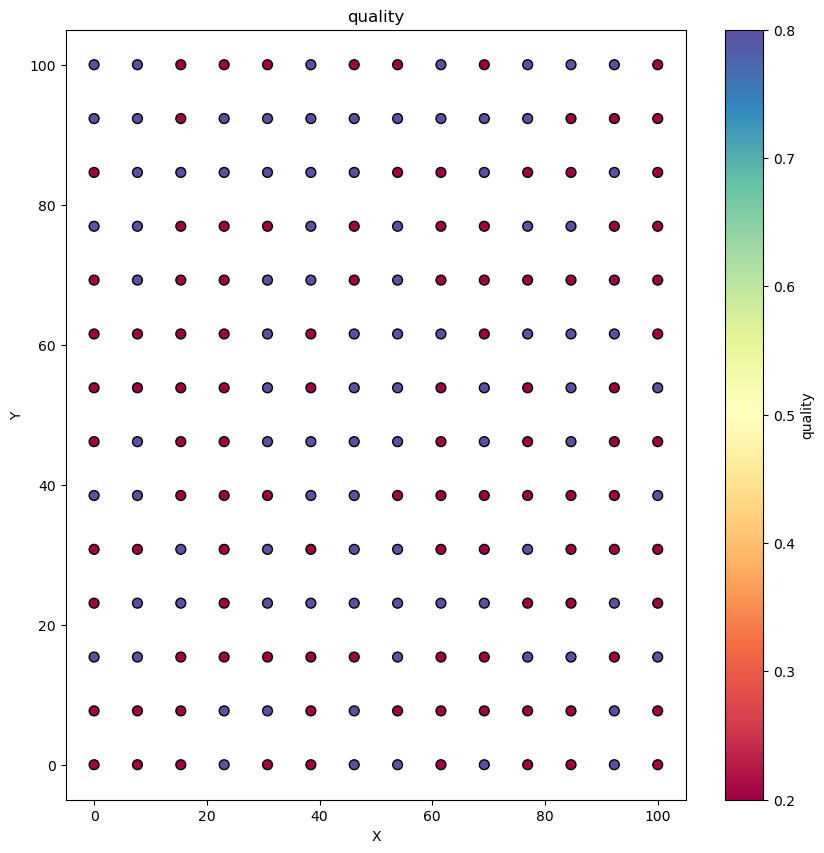

In [7]:
# Create a scatter plot
fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(df['x'], df['y'], c=df['quality'], cmap='Spectral', s=50, edgecolors='k')

# Add colorbar and labels
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('quality')
ax.set_title('quality')
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.show()

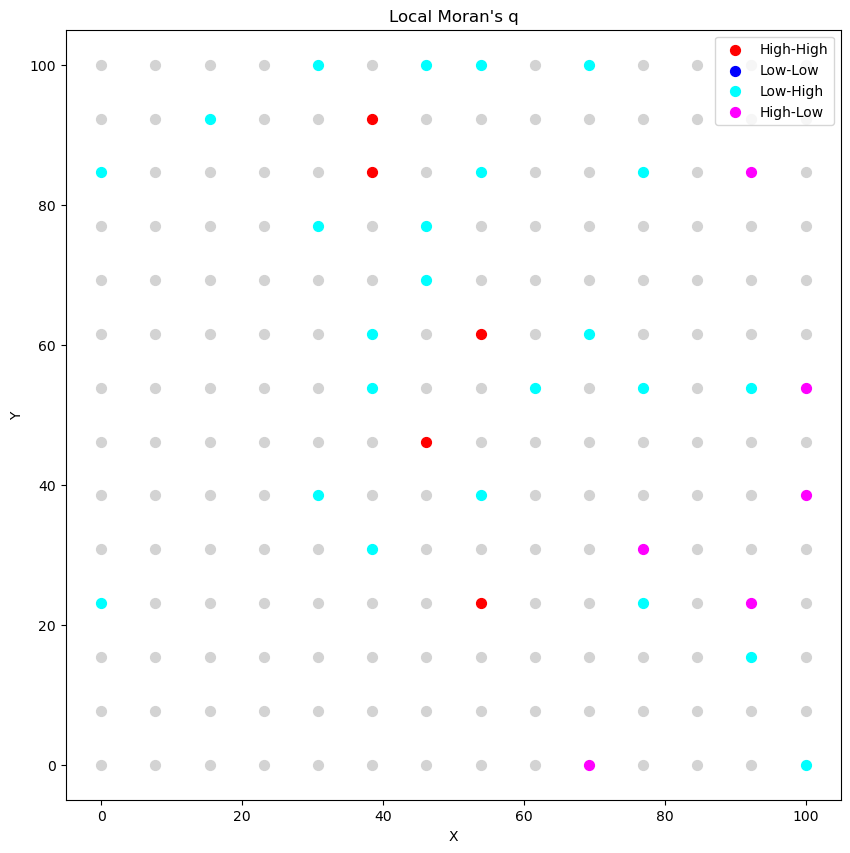

In [8]:
# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

# Plot insignificant observations (p > 0.05) in light gray
insignificant = (local_moran.p_sim > 0.05)
ax.scatter(df['x'][insignificant], df['y'][insignificant], color='lightgrey', s=50)

# Plot High-High and Low-Low clusters (quadrants 1 and 3)
hh = (local_moran.q==1) & (local_moran.p_sim <= 0.05)
ll = (local_moran.q==3) & (local_moran.p_sim <= 0.05)
ax.scatter(df['x'][hh], df['y'][hh], color='red', s=50, label='High-High')
ax.scatter(df['x'][ll], df['y'][ll], color='blue', s=50, label='Low-Low')

# Plot Low-High and High-Low outliers (quadrants 2 and 4)
lh = (local_moran.q==2) & (local_moran.p_sim <= 0.05)
hl = (local_moran.q==4) & (local_moran.p_sim <= 0.05)
ax.scatter(df['x'][lh], df['y'][lh], color='cyan', s=50, label='Low-High')
ax.scatter(df['x'][hl], df['y'][hl], color='magenta', s=50, label='High-Low')

# Add legend and labels
ax.legend()
ax.set_title('Local Moran\'s q')
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.show()

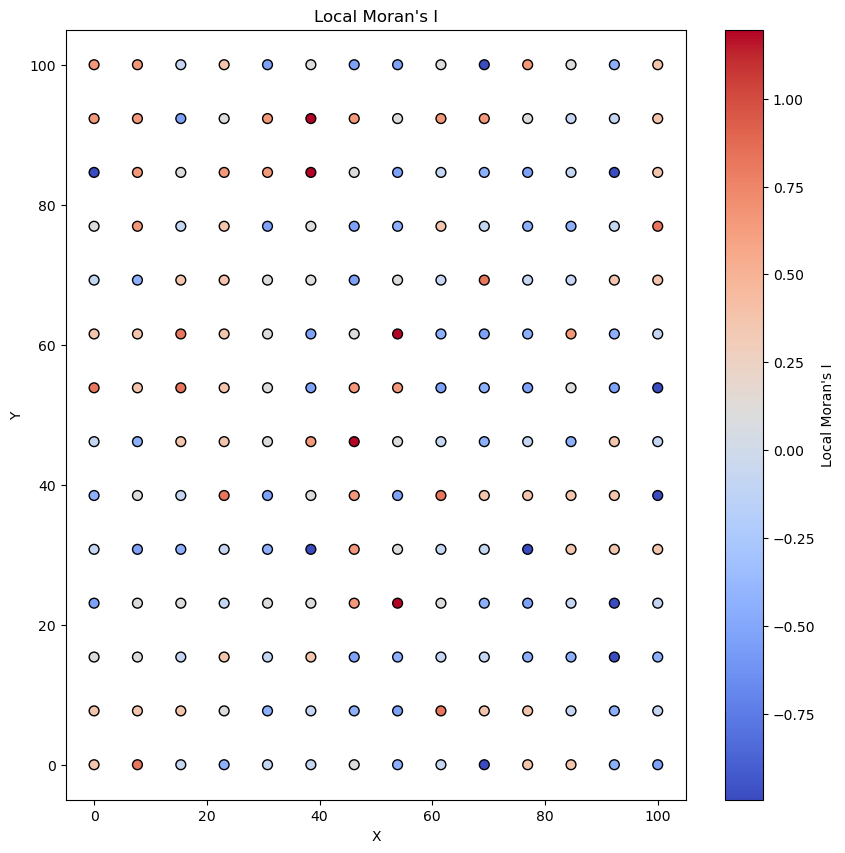

In [9]:
# Create a scatter plot
fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(df['x'], df['y'], c=local_moran.Is, cmap='coolwarm', s=50, edgecolors='k')

# Add colorbar and labels
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Local Moran\'s I')
ax.set_title('Local Moran\'s I')
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.show()

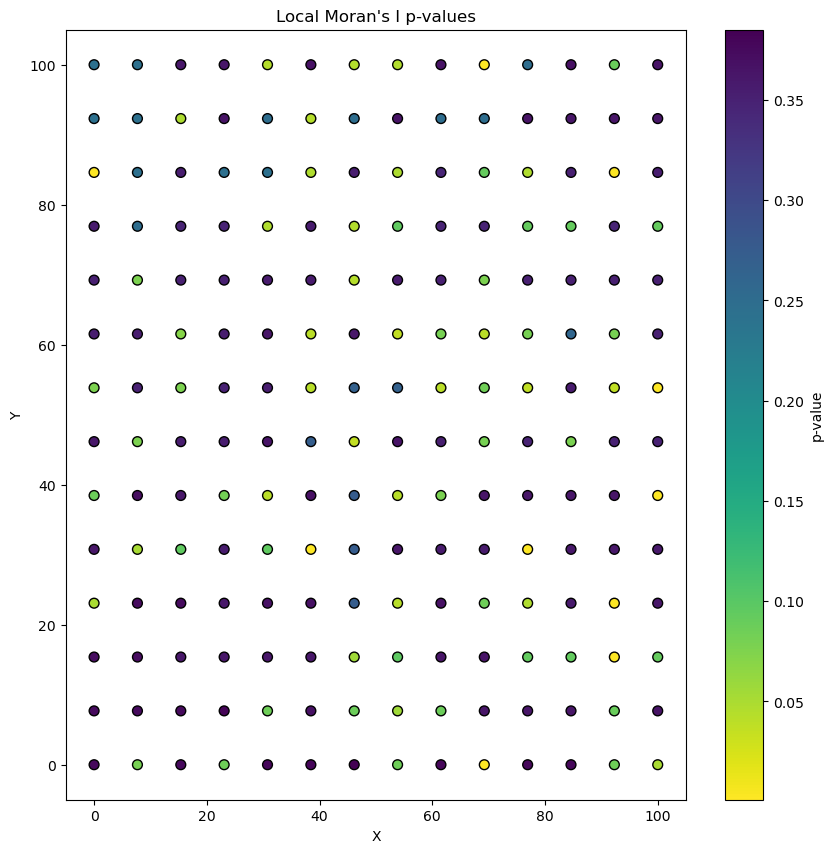

In [10]:
# Create a scatter plot
fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(df['x'], df['y'], c=local_moran.p_sim, cmap='viridis_r', s=50, edgecolors='k')

# Add colorbar and labels
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('p-value')
ax.set_title('Local Moran\'s I p-values')
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.show()